# UNI2 embeddings with Reinhard stain normalization

robustification BEFORE alignment (PathoROB paper). Reinhard normalization maps each
patch's color statistics (mean, std per LAB channel) to a TNBC-representative target.
this reduces slide-level stain variation that UNI2 encodes as real signal.

pipeline: extract patches -> Reinhard normalize -> UNI2 inference -> save embeddings

target selection: use a slide from the alignment training set (TNBC1/TNBC3/TNBC83)
with median stain appearance. NOT TCGA-LUSC (wrong tissue).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import torch
import timm
from torchvision import transforms
from torchstain.torch.normalizers import TorchReinhardNormalizer

Image.MAX_IMAGE_PIXELS = None

ROOT = Path().resolve().parents[1]
DATA = ROOT / 'data' / 'inputs'
by_array = DATA / 'byArray'
hd_dir = DATA / 'Images' / 'imagesHD'

sns.set_theme(style='ticks', palette='Dark2', context='notebook')

## 1. subarray selection and patch extraction

same 5 subarrays as uni2_patch_extraction.ipynb for direct comparison.

In [2]:
# same subarrays as raw UNI2 notebook
SELECTED_SUBARRAYS = [
    ('TNBC55', 'CN28', 'C1'),
    ('TNBC3', 'CN2', 'C1'),
    ('TNBC68', 'CN34', 'D2'),
    ('TNBC83', 'CN42', 'C1'),
    ('TNBC1', 'CN1', 'C1'),
]

# build mapping: find HD image for each subarray
import subprocess, io

subarray_info = []
for tnbc_id, slide, pos in SELECTED_SUBARRAYS:
    hd_path = hd_dir / f'{tnbc_id}_{slide}_{pos}.jpg'
    spot_dir = by_array / slide / pos
    # load spot coordinates from selection.RData
    r = subprocess.run(['Rscript', '-e', f'''
        load("{spot_dir / 'selection.RData'}")
        write.csv(spots, stdout())
    '''], capture_output=True, text=True)
    coords = pd.read_csv(io.StringIO(r.stdout), index_col=0)
    subarray_info.append({
        'key': f'{tnbc_id}_{slide}_{pos}',
        'tnbc_id': tnbc_id,
        'slide': slide,
        'position': pos,
        'hd_path': hd_path,
        'hd_exists': hd_path.exists(),
        'coords': coords,
    })
    print(f'{tnbc_id}_{slide}_{pos}: HD={hd_path.exists()}, spots={len(coords)}')

# filter to subarrays with HD images
subarray_info = [s for s in subarray_info if s['hd_exists']]
print(f'\n{len(subarray_info)} subarrays with HD images')

TNBC55_CN28_C1: HD=True, spots=542
TNBC3_CN2_C1: HD=True, spots=701
TNBC68_CN34_D2: HD=True, spots=697
TNBC83_CN42_C1: HD=True, spots=1398
TNBC1_CN1_C1: HD=True, spots=1075

5 subarrays with HD images


In [3]:
# calibration constants from uni2_patch_extraction.ipynb
HE_SMALL_SIZE = 9523
HD_SIZE = 31744
SCALE_TO_HD = HD_SIZE / HE_SMALL_SIZE

SPOT_SPACING_UM = 200
# hd_pixel_dist was computed as median nearest-neighbor distance in HD space
# from the original notebook: ~547 px at HD resolution
# UM_PER_PIXEL_HD = 200 / 547 ~= 0.366
# but we need the actual value - compute it from one subarray
from scipy.spatial import KDTree

sample = subarray_info[0]
sample_coords_hd = sample['coords'][['pixel_x', 'pixel_y']].values * SCALE_TO_HD
tree = KDTree(sample_coords_hd)
dists, _ = tree.query(sample_coords_hd, k=2)
hd_pixel_dist = np.median(dists[:, 1])
UM_PER_PIXEL_HD = SPOT_SPACING_UM / hd_pixel_dist

UNI2_FOV_UM = 128
PATCH_SIZE_HD = int(round(UNI2_FOV_UM / UM_PER_PIXEL_HD))
UNI2_INPUT_SIZE = 224  # UNI2 native input

print(f'HD resolution: {UM_PER_PIXEL_HD:.4f} um/pixel')
print(f'patch size from HD: {PATCH_SIZE_HD}x{PATCH_SIZE_HD} px')
print(f'resize to: {UNI2_INPUT_SIZE}x{UNI2_INPUT_SIZE} for UNI2')

HD resolution: 0.3785 um/pixel
patch size from HD: 338x338 px
resize to: 224x224 for UNI2


In [4]:
def extract_patches(hd_image_path, spot_df, scale_factor, patch_size_hd, output_size=224):
    """extract patches centered at spot coordinates from an HD H&E image."""
    img = Image.open(hd_image_path)
    w, h = img.size
    half = patch_size_hd // 2
    patches = []
    coords = []

    for _, row in spot_df.iterrows():
        cx = int(round(row['pixel_x'] * scale_factor))
        cy = int(round(row['pixel_y'] * scale_factor))

        x1 = max(0, cx - half)
        y1 = max(0, cy - half)
        x2 = min(w, cx + half)
        y2 = min(h, cy + half)

        patch = img.crop((x1, y1, x2, y2))

        if patch.size != (patch_size_hd, patch_size_hd):
            padded = Image.new('RGB', (patch_size_hd, patch_size_hd), (0, 0, 0))
            paste_x = half - (cx - x1)
            paste_y = half - (cy - y1)
            padded.paste(patch, (paste_x, paste_y))
            patch = padded

        patch = patch.resize((output_size, output_size), Image.LANCZOS)
        patches.append(patch)
        coords.append((cx, cy))

    img.close()
    return patches, coords

In [5]:
%%time
# extract patches for all subarrays
all_patches = {}
all_hd_coords = {}

for info in subarray_info:
    key = info['key']
    patches, coords = extract_patches(
        info['hd_path'], info['coords'], SCALE_TO_HD, PATCH_SIZE_HD, UNI2_INPUT_SIZE
    )
    all_patches[key] = patches
    all_hd_coords[key] = coords
    print(f'{key}: {len(patches)} patches')

total_patches = sum(len(p) for p in all_patches.values())
print(f'\ntotal: {total_patches} patches')

TNBC55_CN28_C1: 542 patches
TNBC3_CN2_C1: 701 patches
TNBC68_CN34_D2: 697 patches
TNBC83_CN42_C1: 1398 patches
TNBC1_CN1_C1: 1075 patches

total: 4413 patches
CPU times: user 13.3 s, sys: 1.71 s, total: 15 s
Wall time: 15.1 s


## 2. target selection for Reinhard normalization

Reinhard normalization transfers color statistics from a target image to each source.
the target should have representative TNBC stain appearance - median color profile
across the alignment training set (TNBC1, TNBC3, TNBC83).

approach: compute mean LAB statistics for each subarray, pick the one closest to
the grand mean as target.

In [6]:
from skimage import color as skcolor

# compute per-subarray LAB statistics from a sample of patches
N_SAMPLE = 50  # patches per subarray for stats
rng = np.random.RandomState(42)

lab_stats = {}
for key, patches in all_patches.items():
    idx = rng.choice(len(patches), size=min(N_SAMPLE, len(patches)), replace=False)
    lab_means = []
    lab_stds = []
    for i in idx:
        rgb = np.array(patches[i]).astype(np.float64) / 255.0
        lab = skcolor.rgb2lab(rgb)
        # per-channel mean and std (L, a, b)
        lab_means.append(lab.reshape(-1, 3).mean(axis=0))
        lab_stds.append(lab.reshape(-1, 3).std(axis=0))
    lab_stats[key] = {
        'mean': np.mean(lab_means, axis=0),
        'std': np.mean(lab_stds, axis=0),
    }
    print(f'{key}: L={lab_stats[key]["mean"][0]:.1f} a={lab_stats[key]["mean"][1]:.1f} b={lab_stats[key]["mean"][2]:.1f}')

# alignment training set only
train_keys = [k for k in lab_stats if any(t in k for t in ['TNBC1_', 'TNBC3_', 'TNBC83_'])]
grand_mean = np.mean([lab_stats[k]['mean'] for k in train_keys], axis=0)
print(f'\ngrand mean (train set): L={grand_mean[0]:.1f} a={grand_mean[1]:.1f} b={grand_mean[2]:.1f}')

# pick training subarray closest to grand mean
dists_to_mean = {k: np.linalg.norm(lab_stats[k]['mean'] - grand_mean) for k in train_keys}
target_key = min(dists_to_mean, key=dists_to_mean.get)
print(f'target subarray: {target_key} (dist={dists_to_mean[target_key]:.2f})')

# show all distances
for k, d in sorted(dists_to_mean.items(), key=lambda x: x[1]):
    marker = ' <- TARGET' if k == target_key else ''
    print(f'  {k}: {d:.2f}{marker}')

TNBC55_CN28_C1: L=55.0 a=13.6 b=-18.7
TNBC3_CN2_C1: L=48.4 a=11.3 b=-17.2
TNBC68_CN34_D2: L=47.6 a=18.4 b=-23.1
TNBC83_CN42_C1: L=47.1 a=14.5 b=-22.0
TNBC1_CN1_C1: L=49.2 a=20.0 b=-20.5

grand mean (train set): L=48.2 a=15.3 b=-19.9
target subarray: TNBC83_CN42_C1 (dist=2.48)
  TNBC83_CN42_C1: 2.48 <- TARGET
  TNBC3_CN2_C1: 4.77
  TNBC1_CN1_C1: 4.85


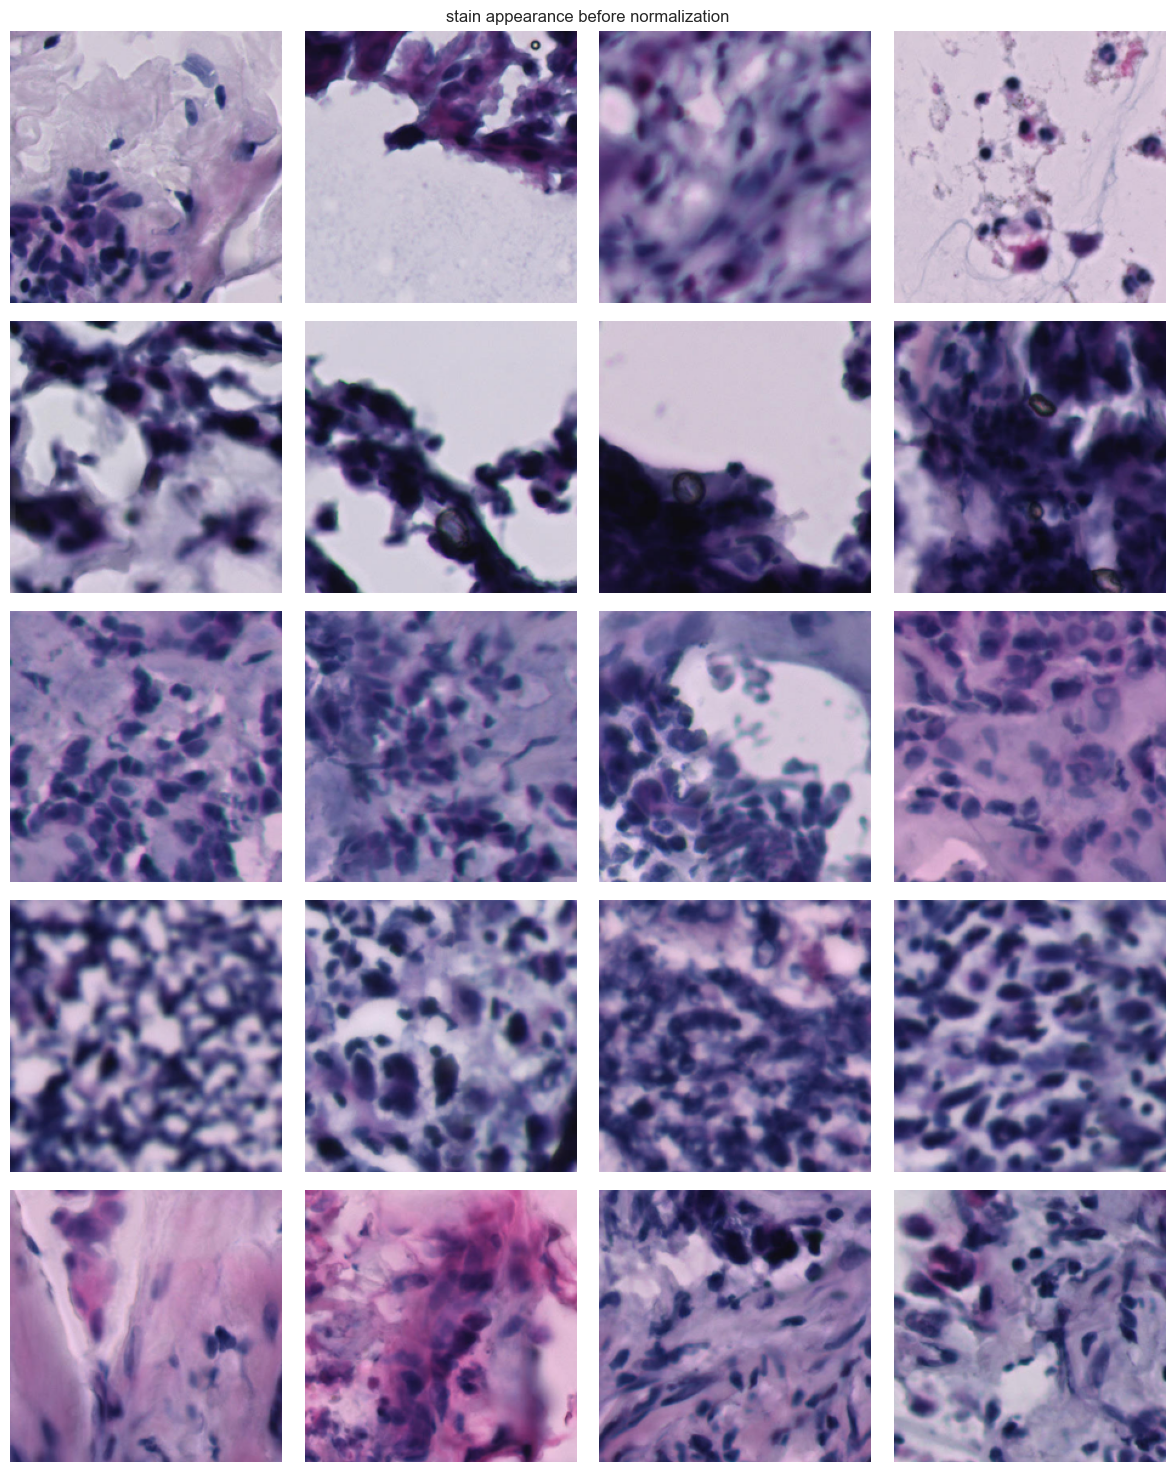

In [7]:
# visualize stain appearance across subarrays - 4 patches each
n_show = 4
fig, axes = plt.subplots(len(all_patches), n_show, figsize=(3 * n_show, 3 * len(all_patches)))

for i, (key, patches) in enumerate(all_patches.items()):
    idx = rng.choice(len(patches), size=n_show, replace=False)
    for j, pi in enumerate(idx):
        axes[i, j].imshow(patches[pi])
        axes[i, j].axis('off')
    label = f'{key}'
    if key == target_key:
        label += ' (TARGET)'
    axes[i, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=120, va='center')

plt.suptitle('stain appearance before normalization', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Reinhard stain normalization

torchstain's TorchReinhardNormalizer fits on a target image, then normalizes sources
to match the target's LAB channel statistics (mean, std per channel).

In [8]:
# fit Reinhard normalizer on target patches
# torchstain expects (3, H, W) uint8 [0-255] tensors for both fit() and normalize()
# do NOT use transforms.ToTensor() which scales to [0, 1] - torchstain divides by 255 internally

def pil_to_chw_uint8(pil_img):
    """PIL -> (3, H, W) uint8 tensor (torchstain's expected format)"""
    return torch.from_numpy(np.array(pil_img)).permute(2, 0, 1).contiguous()

target_patches = all_patches[target_key]
n_target = min(100, len(target_patches))
target_idx = rng.choice(len(target_patches), size=n_target, replace=False)

# stack target patches into a single composite image for robust LAB statistics
cols = int(np.ceil(np.sqrt(n_target)))
rows = int(np.ceil(n_target / cols))
composite = Image.new('RGB', (cols * UNI2_INPUT_SIZE, rows * UNI2_INPUT_SIZE))
for idx_i, pi in enumerate(target_idx):
    r, c = divmod(idx_i, cols)
    composite.paste(target_patches[pi], (c * UNI2_INPUT_SIZE, r * UNI2_INPUT_SIZE))

# fit normalizer
normalizer = TorchReinhardNormalizer()
normalizer.fit(pil_to_chw_uint8(composite))
print(f'Reinhard normalizer fitted on {n_target} patches from {target_key}')

Reinhard normalizer fitted on 100 patches from TNBC83_CN42_C1


In [9]:
%%time
# normalize all patches
# torchstain normalize returns (H, W, 3) uint8 tensor

all_patches_norm = {}
norm_failures = {}

for key, patches in all_patches.items():
    normed = []
    fails = 0
    for p in patches:
        try:
            t = pil_to_chw_uint8(p)
            result = normalizer.normalize(t)
            # result is (H, W, 3) uint8 - convert back to PIL
            normed.append(Image.fromarray(result.numpy()))
        except Exception:
            # fallback: keep original if normalization fails (ex. near-white patches)
            normed.append(p)
            fails += 1
    all_patches_norm[key] = normed
    norm_failures[key] = fails
    print(f'{key}: {len(normed)} normalized ({fails} failures kept as-is)')

total_fails = sum(norm_failures.values())
print(f'\ntotal normalization failures: {total_fails}/{total_patches} ({100*total_fails/total_patches:.1f}%)')

TNBC55_CN28_C1: 542 normalized (0 failures kept as-is)
TNBC3_CN2_C1: 701 normalized (0 failures kept as-is)
TNBC68_CN34_D2: 697 normalized (0 failures kept as-is)
TNBC83_CN42_C1: 1398 normalized (0 failures kept as-is)
TNBC1_CN1_C1: 1075 normalized (0 failures kept as-is)

total normalization failures: 0/4413 (0.0%)
CPU times: user 41.7 s, sys: 42.3 s, total: 1min 24s
Wall time: 31 s


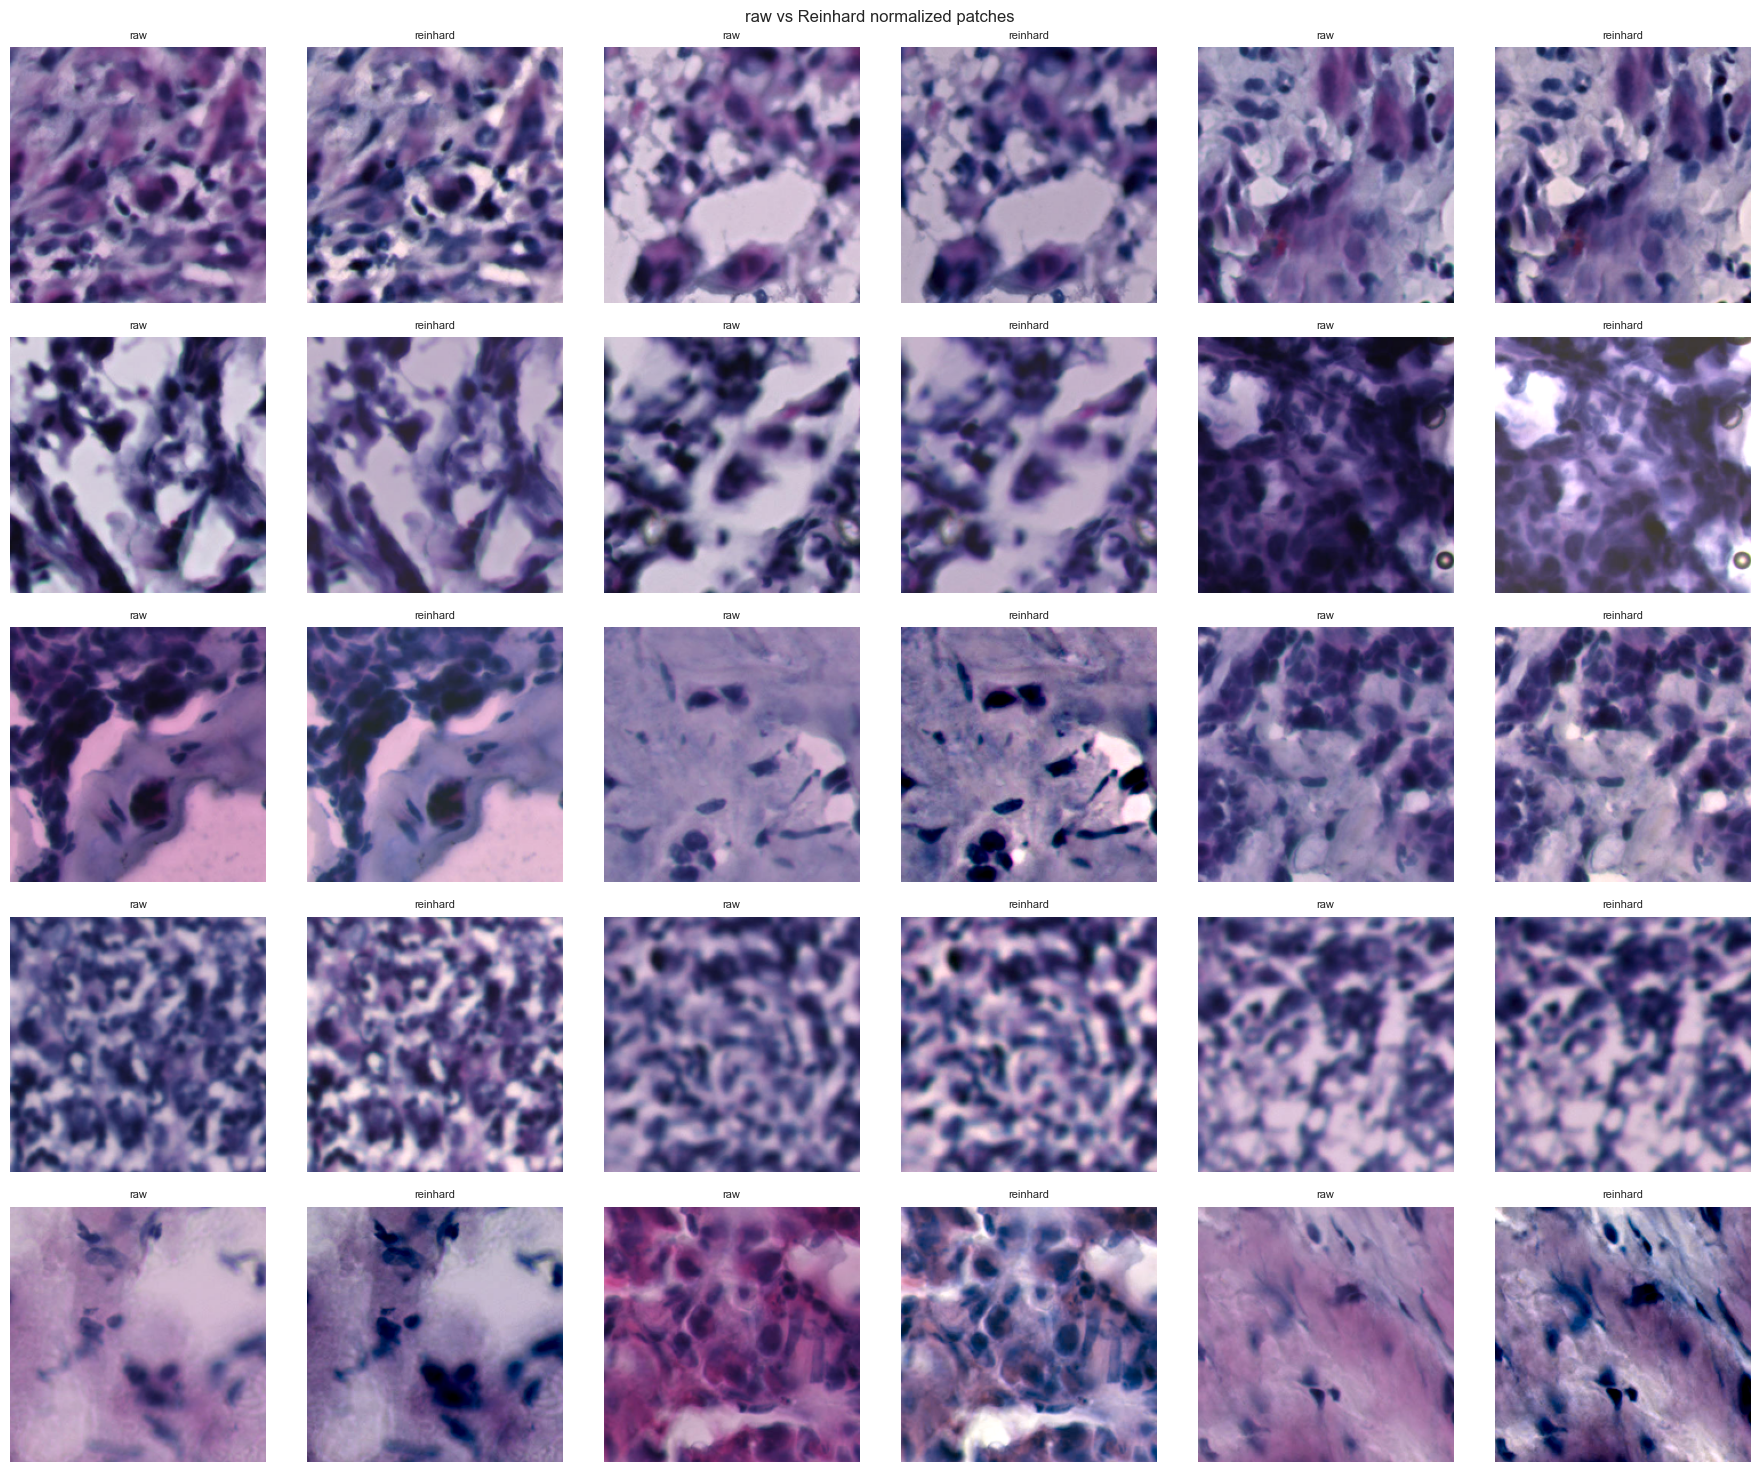

In [10]:
# visual comparison: raw vs normalized for each subarray
n_show = 3
fig, axes = plt.subplots(len(all_patches), n_show * 2, figsize=(3 * n_show * 2, 3 * len(all_patches)))

for i, key in enumerate(all_patches.keys()):
    idx = rng.choice(len(all_patches[key]), size=n_show, replace=False)
    for j, pi in enumerate(idx):
        # raw
        axes[i, j * 2].imshow(all_patches[key][pi])
        axes[i, j * 2].set_title('raw', fontsize=8)
        axes[i, j * 2].axis('off')
        # normalized
        axes[i, j * 2 + 1].imshow(all_patches_norm[key][pi])
        axes[i, j * 2 + 1].set_title('reinhard', fontsize=8)
        axes[i, j * 2 + 1].axis('off')
    axes[i, 0].set_ylabel(key, fontsize=9, rotation=0, labelpad=100, va='center')

plt.suptitle('raw vs Reinhard normalized patches', fontsize=12)
plt.tight_layout()
plt.show()

## 4. UNI2 inference on Reinhard-normalized patches

In [11]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {device}')

# load UNI2-h
timm_kwargs = {
    'img_size': 224,
    'patch_size': 14,
    'depth': 24,
    'num_heads': 24,
    'init_values': 1e-5,
    'embed_dim': 1536,
    'mlp_ratio': 2.66667 * 2,
    'num_classes': 0,
    'no_embed_class': True,
    'mlp_layer': timm.layers.SwiGLUPacked,
    'act_layer': torch.nn.SiLU,
    'reg_tokens': 8,
    'dynamic_img_size': True,
}

model = timm.create_model('hf-hub:MahmoodLab/UNI2-h', pretrained=True, **timm_kwargs)

from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
uni2_transform = create_transform(**resolve_data_config(model.pretrained_cfg, model=model))

model = model.to(device)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'UNI2-h loaded: {n_params / 1e6:.0f}M params on {device}')

device: mps
UNI2-h loaded: 681M params on mps


In [12]:
def embed_patches(patch_list, model, transform, device, batch_size=32):
    """compute UNI2 embeddings for a list of PIL patches."""
    embeddings = []
    n = len(patch_list)

    for i in range(0, n, batch_size):
        batch_pil = patch_list[i:i + batch_size]
        batch_tensors = torch.stack([transform(p) for p in batch_pil]).to(device)

        with torch.no_grad():
            emb = model(batch_tensors)

        embeddings.append(emb.cpu().numpy())

        if (i + batch_size) % (batch_size * 10) == 0 or i + batch_size >= n:
            print(f'  {min(i + batch_size, n)}/{n}', end='\r')

    print()
    return np.vstack(embeddings)

In [13]:
%%time
# embed Reinhard-normalized patches
all_embeddings_reinhard = {}
for key, patches in all_patches_norm.items():
    print(f'{key}: {len(patches)} patches')
    emb = embed_patches(patches, model, uni2_transform, device, batch_size=32)
    all_embeddings_reinhard[key] = emb
    print(f'  shape: {emb.shape}')

# stack
embeddings_reinhard = np.vstack(list(all_embeddings_reinhard.values()))
labels_reinhard = np.concatenate([[k] * len(v) for k, v in all_embeddings_reinhard.items()])
print(f'\ntotal: {embeddings_reinhard.shape}')

TNBC55_CN28_C1: 542 patches
  542/542
  shape: (542, 1536)
TNBC3_CN2_C1: 701 patches
  701/701
  shape: (701, 1536)
TNBC68_CN34_D2: 697 patches
  697/697
  shape: (697, 1536)
TNBC83_CN42_C1: 1398 patches
  1398/1398
  shape: (1398, 1536)
TNBC1_CN1_C1: 1075 patches
  1075/1075
  shape: (1075, 1536)

total: (4413, 1536)
CPU times: user 13.7 s, sys: 14 s, total: 27.7 s
Wall time: 6min 29s


## 5. save embeddings

In [14]:
# save Reinhard embeddings
out_dir = ROOT / 'data' / 'embeddings' / 'uni2_reinhard'
out_dir.mkdir(parents=True, exist_ok=True)

for key, emb in all_embeddings_reinhard.items():
    np.save(out_dir / f'{key}.npy', emb)
np.save(out_dir / 'all_embeddings.npy', embeddings_reinhard)
np.save(out_dir / 'all_labels.npy', labels_reinhard)

# save normalization metadata
import json
meta = {
    'target_subarray': target_key,
    'target_lab_mean': lab_stats[target_key]['mean'].tolist(),
    'target_lab_std': lab_stats[target_key]['std'].tolist(),
    'n_target_patches_for_fit': n_target,
    'norm_failures': norm_failures,
    'total_patches': total_patches,
    'subarrays': list(all_embeddings_reinhard.keys()),
}
with open(out_dir / 'reinhard_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'saved to {out_dir.relative_to(ROOT)}')
for f in sorted(out_dir.iterdir()):
    print(f'  {f.name} ({f.stat().st_size / 1024:.0f} KB)')

saved to data/embeddings/uni2_reinhard
  TNBC1_CN1_C1.npy (6450 KB)
  TNBC3_CN2_C1.npy (4206 KB)
  TNBC55_CN28_C1.npy (3252 KB)
  TNBC68_CN34_D2.npy (4182 KB)
  TNBC83_CN42_C1.npy (8388 KB)
  all_embeddings.npy (26478 KB)
  all_labels.npy (241 KB)
  reinhard_meta.json (1 KB)


## 6. also save raw UNI2 embeddings (for comparison)

the original uni2_patch_extraction.ipynb didn't save embeddings to disk.
run inference on raw patches too so we have a direct comparison.

In [15]:
%%time
# embed raw (un-normalized) patches
all_embeddings_raw = {}
for key, patches in all_patches.items():
    print(f'{key}: {len(patches)} patches')
    emb = embed_patches(patches, model, uni2_transform, device, batch_size=32)
    all_embeddings_raw[key] = emb
    print(f'  shape: {emb.shape}')

embeddings_raw = np.vstack(list(all_embeddings_raw.values()))
labels_raw = np.concatenate([[k] * len(v) for k, v in all_embeddings_raw.items()])
print(f'\ntotal: {embeddings_raw.shape}')

# save
raw_dir = ROOT / 'data' / 'embeddings' / 'uni2_raw'
raw_dir.mkdir(parents=True, exist_ok=True)
for key, emb in all_embeddings_raw.items():
    np.save(raw_dir / f'{key}.npy', emb)
np.save(raw_dir / 'all_embeddings.npy', embeddings_raw)
np.save(raw_dir / 'all_labels.npy', labels_raw)
print(f'saved raw embeddings to {raw_dir.relative_to(ROOT)}')

TNBC55_CN28_C1: 542 patches
  542/542
  shape: (542, 1536)
TNBC3_CN2_C1: 701 patches
  701/701
  shape: (701, 1536)
TNBC68_CN34_D2: 697 patches
  697/697
  shape: (697, 1536)
TNBC83_CN42_C1: 1398 patches
  1398/1398
  shape: (1398, 1536)
TNBC1_CN1_C1: 1075 patches
  1075/1075
  shape: (1075, 1536)

total: (4413, 1536)
saved raw embeddings to data/embeddings/uni2_raw
CPU times: user 8.36 s, sys: 11.1 s, total: 19.4 s
Wall time: 6min 38s


## 7. raw vs Reinhard embedding comparison

per-patch cosine similarity (raw vs Reinhard):
  mean=0.9313, std=0.0730
  min=0.2137, max=0.9989


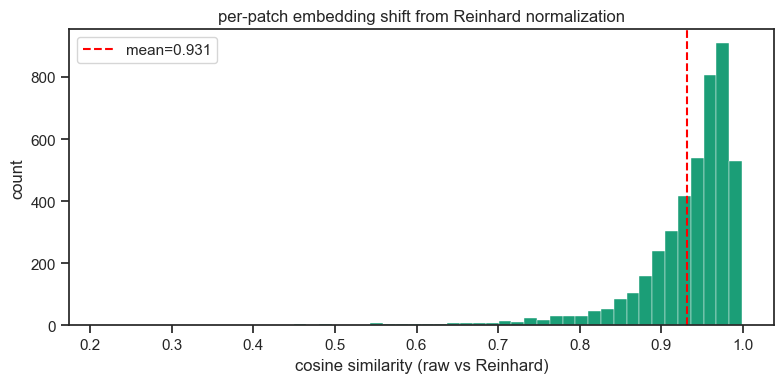

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# per-patch cosine similarity between raw and Reinhard embeddings
# measures how much Reinhard normalization changes each spot's representation
per_patch_sim = np.array([
    cosine_similarity(embeddings_raw[i:i+1], embeddings_reinhard[i:i+1])[0, 0]
    for i in range(len(embeddings_raw))
])

print(f'per-patch cosine similarity (raw vs Reinhard):')
print(f'  mean={per_patch_sim.mean():.4f}, std={per_patch_sim.std():.4f}')
print(f'  min={per_patch_sim.min():.4f}, max={per_patch_sim.max():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_patch_sim, bins=50, edgecolor='white', linewidth=0.3)
ax.axvline(per_patch_sim.mean(), color='red', ls='--', label=f'mean={per_patch_sim.mean():.3f}')
ax.set_xlabel('cosine similarity (raw vs Reinhard)')
ax.set_ylabel('count')
ax.set_title('per-patch embedding shift from Reinhard normalization')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# patient gap: within-patient vs between-patient cosine similarity
# lower gap after Reinhard = less slide-level batch effect encoded

def compute_gap(embeddings, labels, n_sample=500):
    """compute within-patient vs between-patient cosine sim gap."""
    rng = np.random.RandomState(42)
    idx = rng.choice(len(embeddings), size=min(n_sample, len(embeddings)), replace=False)
    sub_emb = embeddings[idx]
    sub_labels = np.array(labels)[idx]
    cos = cosine_similarity(sub_emb)
    triu = np.triu_indices(len(idx), k=1)
    
    same = sub_labels[triu[0]] == sub_labels[triu[1]]
    within = cos[triu][same].mean()
    between = cos[triu][~same].mean()
    return within, between, within - between

w_raw, b_raw, gap_raw = compute_gap(embeddings_raw, labels_raw)
w_rein, b_rein, gap_rein = compute_gap(embeddings_reinhard, labels_reinhard)

print(f'raw:      within={w_raw:.4f}  between={b_raw:.4f}  gap={gap_raw:.4f}')
print(f'reinhard: within={w_rein:.4f}  between={b_rein:.4f}  gap={gap_rein:.4f}')
print(f'gap change: {gap_raw:.4f} -> {gap_rein:.4f} ({100*(gap_rein-gap_raw)/gap_raw:+.1f}%)')

raw:      within=0.4806  between=0.3431  gap=0.1375
reinhard: within=0.4681  between=0.3368  gap=0.1313
gap change: 0.1375 -> 0.1313 (-4.6%)


In [18]:
# spatial autocorrelation: Spearman rho between physical distance and embedding distance
# for each subarray, compare raw vs Reinhard

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

print('spatial autocorrelation (Spearman rho, distance vs 1-cosine):')
print(f'{"subarray":<25} {"raw rho":>10} {"reinhard rho":>15}')
print('-' * 55)

for key in all_embeddings_raw:
    emb_r = all_embeddings_raw[key]
    emb_n = all_embeddings_reinhard[key]
    coords = np.array(all_hd_coords[key])

    n = min(300, len(emb_r))
    idx = rng.choice(len(emb_r), size=n, replace=False)

    phys_dist = pdist(coords[idx])
    emb_dist_raw = pdist(emb_r[idx], metric='cosine')
    emb_dist_norm = pdist(emb_n[idx], metric='cosine')

    rho_raw, _ = spearmanr(phys_dist, emb_dist_raw)
    rho_norm, _ = spearmanr(phys_dist, emb_dist_norm)
    print(f'{key:<25} {rho_raw:>10.3f} {rho_norm:>15.3f}')

spatial autocorrelation (Spearman rho, distance vs 1-cosine):
subarray                     raw rho    reinhard rho
-------------------------------------------------------
TNBC55_CN28_C1                 0.351           0.332
TNBC3_CN2_C1                   0.260           0.237
TNBC68_CN34_D2                 0.208           0.202
TNBC83_CN42_C1                 0.302           0.292
TNBC1_CN1_C1                   0.322           0.313


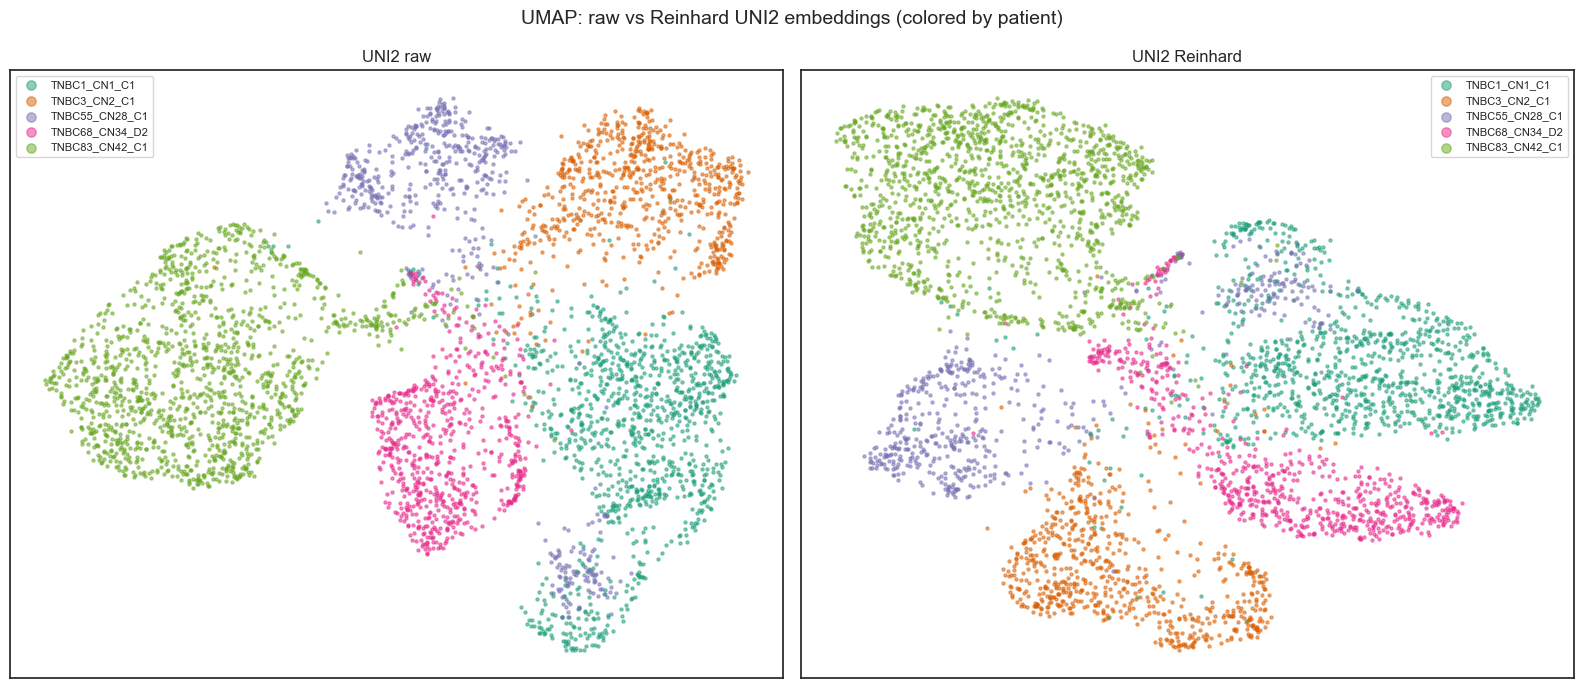

In [19]:
# UMAP comparison: raw vs Reinhard
import warnings
warnings.filterwarnings('ignore', message='.*n_jobs.*')
import umap

# PCA -> UMAP for both
pca_raw = PCA(n_components=50, random_state=42).fit_transform(embeddings_raw)
pca_rein = PCA(n_components=50, random_state=42).fit_transform(embeddings_reinhard)

reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
umap_raw = reducer.fit_transform(pca_raw)
umap_rein = reducer.fit_transform(pca_rein)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unique_labels = sorted(set(labels_raw))
colors = sns.color_palette('Dark2', len(unique_labels))
label_to_color = dict(zip(unique_labels, colors))

for ax, umap_emb, title in [(axes[0], umap_raw, 'UNI2 raw'), (axes[1], umap_rein, 'UNI2 Reinhard')]:
    for label in unique_labels:
        mask = np.array(labels_raw) == label
        ax.scatter(umap_emb[mask, 0], umap_emb[mask, 1],
                   c=[label_to_color[label]], s=5, alpha=0.5, label=label)
    ax.set_title(title, fontsize=12)
    ax.legend(markerscale=3, fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('UMAP: raw vs Reinhard UNI2 embeddings (colored by patient)', fontsize=14)
plt.tight_layout()
plt.show()

## 8. summary

In [20]:
print('=== Reinhard stain normalization summary ===')
print(f'target subarray: {target_key}')
print(f'total patches: {total_patches}')
print(f'normalization failures: {total_fails}')
print(f'per-patch cosine sim (raw vs Reinhard): {per_patch_sim.mean():.4f} +/- {per_patch_sim.std():.4f}')
print(f'patient gap: raw={gap_raw:.4f}, reinhard={gap_rein:.4f} ({100*(gap_rein-gap_raw)/gap_raw:+.1f}%)')
print(f'\noutputs:')
print(f'  data/embeddings/uni2_raw/      - {embeddings_raw.shape}')
print(f'  data/embeddings/uni2_reinhard/  - {embeddings_reinhard.shape}')
print(f'\nnext: alignment experiment comparing raw vs Reinhard UNI2 + Novae')

=== Reinhard stain normalization summary ===
target subarray: TNBC83_CN42_C1
total patches: 4413
normalization failures: 0
per-patch cosine sim (raw vs Reinhard): 0.9313 +/- 0.0730
patient gap: raw=0.1375, reinhard=0.1313 (-4.6%)

outputs:
  data/embeddings/uni2_raw/      - (4413, 1536)
  data/embeddings/uni2_reinhard/  - (4413, 1536)

next: alignment experiment comparing raw vs Reinhard UNI2 + Novae
